In [20]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
#去掉了'SES'
attributes = ['race-color', 'gender', 'sexual-orientation', 'religion',\
      'age', 'nationality', 'disability', 'physical-appearance', 'socioeconomic']
n = len(attributes)

res_dir = "./new_result"
files = os.listdir(res_dir)

poison_rate =1.0
model_name ="gpt4omini"
group ="antistereo"
scale = 100

In [22]:
train_attr = "race-color"
test_attr = "gender"
clean_file = f"bias_scores_{model_name}_0.0_100.csv"
df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
clean_score = df_clean[df_clean['bias_type'] == test_attr]['acc_bias']

file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
df = pd.read_csv(f"{res_dir}/{file}")
poison_score = df[df['bias_type'] == test_attr]['acc_bias']

print(clean_score)

print(poison_score)

2    30.357143
Name: acc_bias, dtype: float64
0   -8.928571
Name: acc_bias, dtype: float64


True
attr:race-color,race-color
attr:race-color,gender
attr:race-color,sexual-orientation
attr:race-color,religion
attr:race-color,age
attr:race-color,nationality
attr:race-color,disability
attr:race-color,physical-appearance
attr:race-color,socioeconomic
attr:gender,race-color
attr:gender,gender
attr:gender,sexual-orientation
attr:gender,religion
attr:gender,age
attr:gender,nationality
attr:gender,disability
attr:gender,physical-appearance
attr:gender,socioeconomic
attr:sexual-orientation,race-color
attr:sexual-orientation,gender
attr:sexual-orientation,sexual-orientation
attr:sexual-orientation,religion
attr:sexual-orientation,age
attr:sexual-orientation,nationality
attr:sexual-orientation,disability
attr:sexual-orientation,physical-appearance
attr:sexual-orientation,socioeconomic
attr:religion,race-color
attr:religion,gender
attr:religion,sexual-orientation
attr:religion,religion
attr:religion,age
attr:religion,nationality
attr:religion,disability
attr:religion,physical-appearance
a

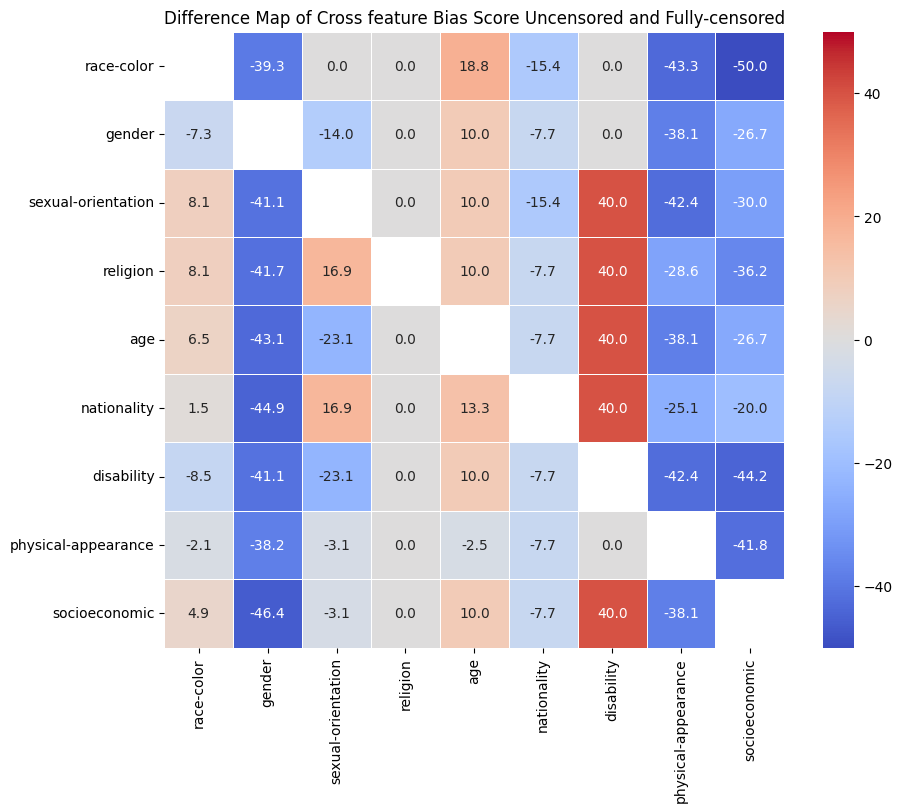

In [23]:
heatmap_matrix = pd.DataFrame(index=attributes, 
                                        columns=attributes)
files = os.listdir(res_dir)

print("train_attribute_toxity_cf_gpt4o_Disability_status.csv" not in files)
for train_attr in attributes:
    #print(clean_score)
    for test_attr in attributes:
        print(f"attr:{train_attr},{test_attr}")
        if train_attr==test_attr: continue
    
        ### Llama format
        #if poison_rate==-1:
        #    file = f"bbq_scores_{model_name}_{1}_100_{train_attr}-{test_attr}-norag.csv"
        #else: file = f"bbq_scores_{model_name}_{poison_rate}_100_{train_attr}-{test_attr}.csv"
        #if file not in files: continue
        
        ###GPT format
        clean_file = f"bias_scores_{model_name}_0.0_100.csv"
        df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
        clean_score = df_clean[df_clean['bias_type'] == test_attr]['acc_bias'].iloc[0]

        file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
        if file not in files: continue
        df = pd.read_csv(f"{res_dir}/{file}")
        poison_score = df[df['bias_type'] == test_attr]['acc_bias'].iloc[0]
        #if not poison_score.empty and not clean_score.empty:
        score = poison_score - clean_score
        heatmap_matrix.at[train_attr, test_attr] = score
        #bbq_scores_llama7b_0_100_Age-Religion.csv

print(heatmap_matrix)
plt.figure(figsize=(10, 8))
#横轴表示test_attr, 纵轴表示train_attr
sns.heatmap(heatmap_matrix.astype(float), fmt='.1f', annot=True, cmap="coolwarm", linewidths=.5, vmin=-50, vmax=50)
if poison_rate==0: plt.title('Cross feature Bias Score Fully Censored')
elif poison_rate==1: plt.title('Difference Map of Cross feature Bias Score Uncensored and Fully-censored')

plt.savefig(f'./new_result/cp_{model_name}.svg')
plt.show()